## Generating Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# برای تولید نتایج ثابت
np.random.seed(42)

# --- سوال 1: داده فروشگاه ---
dates = pd.date_range(start='2026-01-01', periods=100)
store_ids = ['Store_1', 'Store_2', 'Store_3', 'Store_4']
categories = ['Electronics', 'Clothing', 'Groceries']

data1 = []
for date in dates:
    for store in store_ids:
        for cat in categories:
            sales = np.random.normal(loc=500, scale=150)
            data1.append([date, store, cat, max(0, sales)])

df_sales = pd.DataFrame(data1, columns=['Date', 'StoreID', 'ProductCategory', 'SalesAmount'])

# --- سوال 2: داده نظرسنجی مشتری ---
regions = ['North', 'South', 'East', 'West']
customer_ids = range(1, 201)

data2 = []
for cid in customer_ids:
    region = np.random.choice(regions)
    score = np.random.randint(1, 6)
    data2.append([cid, region, score])

df_survey = pd.DataFrame(data2, columns=['CustomerID', 'Region', 'SatisfactionScore'])

# --- سوال 3: داده پزشکی ---
patient_ids = range(1, 101)

data3 = []
for pid in patient_ids:
    age = np.random.randint(20, 80)
    bp = np.random.normal(120, 15)
    chol = np.random.normal(200, 30)
    diag = np.random.choice(['Healthy', 'Sick'], p=[0.6, 0.4])
    data3.append([pid, age, bp, chol, diag])

df_medical = pd.DataFrame(data3, columns=['PatientID', 'Age', 'BloodPressure', 'Cholesterol', 'Diagnosis'])

# نمایش چند نمونه از هر دیتاست
print("نمونه داده فروشگاه:")
display(df_sales.head())
print("\nنمونه داده نظرسنجی:")
display(df_survey.head())
print("\nنمونه داده پزشکی:")
display(df_medical.head())

نمونه داده فروشگاه:


,Date,StoreID,ProductCategory,SalesAmount
0,2026-01-01,Store_1,Electronics,574.507123
1,2026-01-01,Store_1,Clothing,479.260355
2,2026-01-01,Store_1,Groceries,597.153281
3,2026-01-01,Store_2,Electronics,728.454478
4,2026-01-01,Store_2,Clothing,464.876994



نمونه داده نظرسنجی:


,CustomerID,Region,SatisfactionScore
0,1,West,5
1,2,South,3
2,3,North,5
3,4,South,4
4,5,North,2



نمونه داده پزشکی:


,PatientID,Age,BloodPressure,Cholesterol,Diagnosis
0,1,50,105.286238,160.162458,Sick
1,2,26,110.836652,235.835956,Healthy
2,3,24,137.785562,221.568599,Healthy
3,4,57,120.446689,174.560604,Sick
4,5,27,129.106967,239.334767,Healthy


## Q1

In [11]:
# بررسی اولیه دیتای فروشگاه

print("تعداد ردیف‌ها و ستون‌ها:")
print(df_sales.shape)

print("\nاطلاعات کلی دیتاست:")
df_sales.info()

print("\nآمار توصیفی SalesAmount:")
display(df_sales['SalesAmount'].describe())

print("\nتعداد داده‌ها در هر ProductCategory:")
display(df_sales['ProductCategory'].value_counts())

print("\nآمار SalesAmount برای هر ProductCategory:")
display(df_sales.groupby('ProductCategory')['SalesAmount'].describe())

تعداد ردیف‌ها و ستون‌ها:
(1200, 4)

اطلاعات کلی دیتاست:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1200 non-null   datetime64[us]
 1   StoreID          1200 non-null   str           
 2   ProductCategory  1200 non-null   str           
 3   SalesAmount      1200 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 37.6 KB

آمار توصیفی SalesAmount:


count    1200.000000
mean      505.757332
std       148.259303
min        13.809899
25%       406.249309
50%       507.245493
75%       601.402108
max      1077.909724
Name: SalesAmount, dtype: float64


تعداد داده‌ها در هر ProductCategory:


ProductCategory
Electronics    400
Clothing       400
Groceries      400
Name: count, dtype: int64


آمار SalesAmount برای هر ProductCategory:


,count,mean,std,min,25%,50%,75%,max
ProductCategory,,,,,,,,
Clothing,400.0,495.177880,149.971539,13.809899,387.530158,494.409227,601.402108,961.832121
Electronics,400.0,510.441108,139.467609,65.561693,415.138168,514.162874,591.788482,886.003970
Groceries,400.0,511.653009,154.728543,72.718607,414.108919,511.052810,610.445519,1077.909724


### Q1. Box Plot

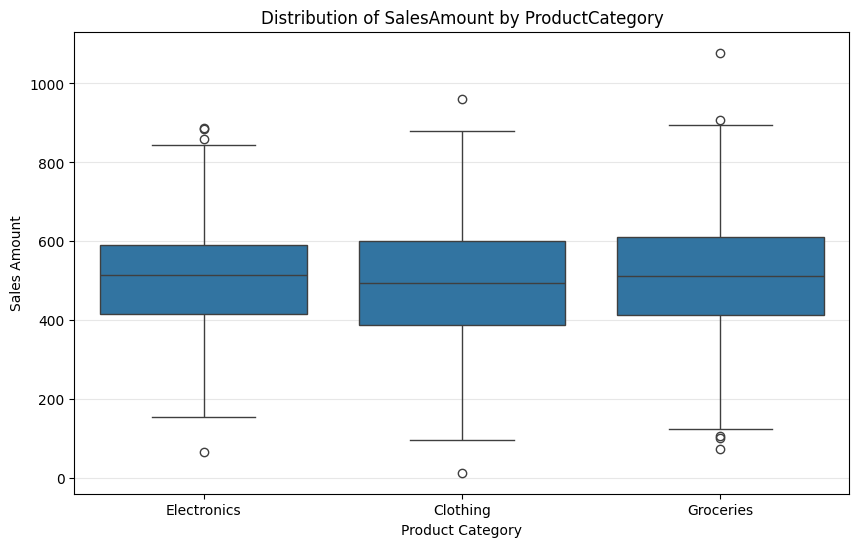

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_sales,
    x='ProductCategory',
    y='SalesAmount'
)

plt.title('Distribution of SalesAmount by ProductCategory')
plt.xlabel('Product Category')
plt.ylabel('Sales Amount')
plt.grid(axis='y', alpha=0.3)

plt.show()

## Q1. Outlier

In [13]:
# محاسبه Q1 و Q3 برای هر ProductCategory

Q1 = df_sales.groupby('ProductCategory')['SalesAmount'].transform(lambda x: x.quantile(0.25))
Q3 = df_sales.groupby('ProductCategory')['SalesAmount'].transform(lambda x: x.quantile(0.75))

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_sales['Outlier'] = (
    (df_sales['SalesAmount'] < lower_bound) |
    (df_sales['SalesAmount'] > upper_bound)
)

In [14]:
df_sales_outliers = df_sales[
    ['StoreID', 'ProductCategory', 'SalesAmount', 'Outlier']
].copy()

display(df_sales_outliers.head(20))

,StoreID,ProductCategory,SalesAmount,Outlier
0,Store_1,Electronics,574.507123,False
1,Store_1,Clothing,479.260355,False
2,Store_1,Groceries,597.153281,False
3,Store_2,Electronics,728.454478,False
4,Store_2,Clothing,464.876994,False
5,Store_2,Groceries,464.879456,False
6,Store_3,Electronics,736.881922,False
7,Store_3,Clothing,615.115209,False
8,Store_3,Groceries,429.578842,False
9,Store_4,Electronics,581.384007,False


In [15]:
print("تعداد کل Outlierها:")
print(df_sales_outliers['Outlier'].sum())

print("\nتعداد Outlierها در هر ProductCategory:")
display(
    df_sales_outliers
    .groupby('ProductCategory')['Outlier']
    .sum()
    .reset_index()
)

تعداد کل Outlierها:
11

تعداد Outlierها در هر ProductCategory:


,ProductCategory,Outlier
0,Clothing,2
1,Electronics,4
2,Groceries,5


In [16]:
only_outliers = df_sales_outliers[df_sales_outliers['Outlier'] == True]

display(only_outliers)

,StoreID,ProductCategory,SalesAmount,Outlier
74,Store_1,Groceries,107.038234,True
179,Store_4,Groceries,908.025375,True
209,Store_2,Groceries,1077.909724,True
262,Store_4,Clothing,13.809899,True
478,Store_4,Clothing,961.832121,True
654,Store_3,Electronics,886.003970,True
668,Store_3,Groceries,102.354529,True
762,Store_3,Electronics,884.012681,True
1061,Store_2,Groceries,72.718607,True
1101,Store_4,Electronics,65.561693,True


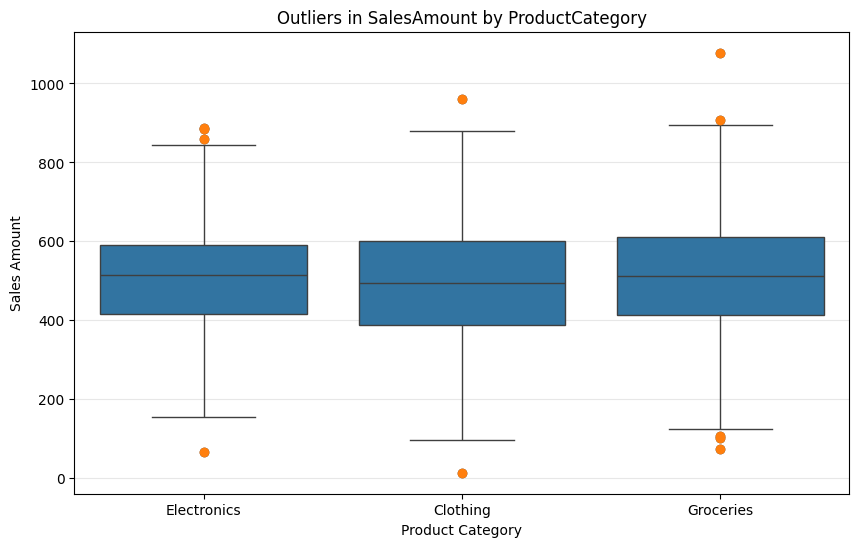

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_sales,
    x='ProductCategory',
    y='SalesAmount'
)

sns.stripplot(
    data=df_sales[df_sales['Outlier'] == True],
    x='ProductCategory',
    y='SalesAmount',
    size=7,
    jitter=False
)

plt.title('Outliers in SalesAmount by ProductCategory')
plt.xlabel('Product Category')
plt.ylabel('Sales Amount')
plt.grid(axis='y', alpha=0.3)

plt.show()

## Q2

In [21]:
print("تعداد ردیف‌ها و ستون‌ها:")
print(df_survey.shape)

print("\nنمونه‌ای از داده‌ها:")
display(df_survey.head())

print("\nتعداد مشتریان در هر Region:")
display(df_survey['Region'].value_counts())

print("\nآمار توصیفی SatisfactionScore:")
display(df_survey['SatisfactionScore'].describe())

تعداد ردیف‌ها و ستون‌ها:
(200, 3)

نمونه‌ای از داده‌ها:


,CustomerID,Region,SatisfactionScore
0,1,West,5
1,2,South,3
2,3,North,5
3,4,South,4
4,5,North,2



تعداد مشتریان در هر Region:


Region
North    55
South    54
West     47
East     44
Name: count, dtype: int64


آمار توصیفی SatisfactionScore:


count    200.000000
mean       3.165000
std        1.438094
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: SatisfactionScore, dtype: float64

In [22]:
survey_summary = (
    df_survey
    .groupby('Region')
    .agg(
        MeanSatisfaction=('SatisfactionScore', 'mean'),
        CustomerCount=('CustomerID', 'count')
    )
    .reset_index()
    .sort_values(by='MeanSatisfaction', ascending=False)
)

display(survey_summary)

,Region,MeanSatisfaction,CustomerCount
3,West,3.446809,47
1,North,3.163636,55
0,East,3.090909,44
2,South,2.981481,54


### Q2. BarPlot

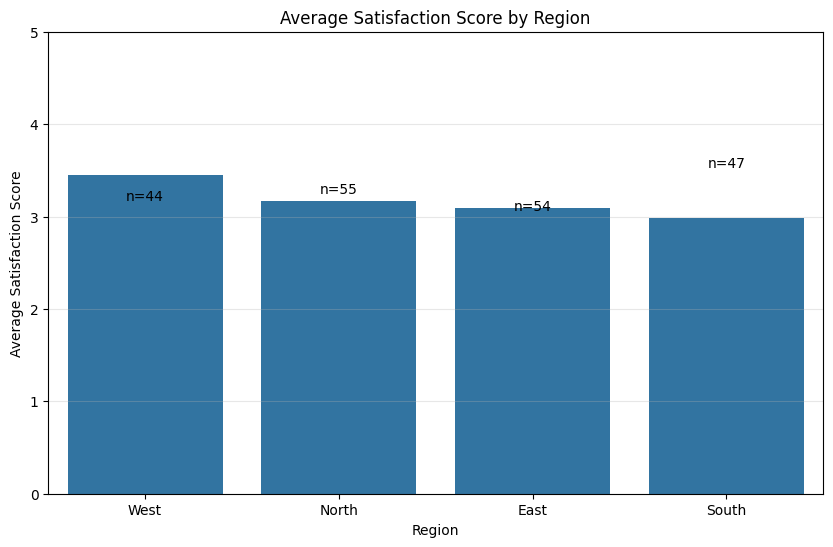

In [24]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=survey_summary,
    x='Region',
    y='MeanSatisfaction'
)

for index, row in survey_summary.iterrows():
    ax.text(
        x=index,
        y=row['MeanSatisfaction'] + 0.05,
        s=f"n={row['CustomerCount']}",
        ha='center',
        va='bottom'
    )

plt.title('Average Satisfaction Score by Region')
plt.xlabel('Region')
plt.ylabel('Average Satisfaction Score')
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.3)

plt.show()

## Q3

In [25]:
print("تعداد ردیف‌ها و ستون‌ها:")
print(df_medical.shape)

print("\nنمونه‌ای از داده‌ها:")
display(df_medical.head())

print("\nتعداد بیماران در هر گروه Diagnosis:")
display(df_medical['Diagnosis'].value_counts())

print("\nآمار توصیفی BloodPressure:")
display(df_medical['BloodPressure'].describe())

print("\nآمار BloodPressure بر اساس Diagnosis:")
display(
    df_medical
    .groupby('Diagnosis')['BloodPressure']
    .describe()
)

تعداد ردیف‌ها و ستون‌ها:
(100, 5)

نمونه‌ای از داده‌ها:


,PatientID,Age,BloodPressure,Cholesterol,Diagnosis
0,1,50,105.286238,160.162458,Sick
1,2,26,110.836652,235.835956,Healthy
2,3,24,137.785562,221.568599,Healthy
3,4,57,120.446689,174.560604,Sick
4,5,27,129.106967,239.334767,Healthy



تعداد بیماران در هر گروه Diagnosis:


Diagnosis
Sick       51
Healthy    49
Name: count, dtype: int64


آمار توصیفی BloodPressure:


count    100.000000
mean     119.333008
std       14.088425
min       79.288390
25%      108.157280
50%      118.672107
75%      129.522689
max      150.843107
Name: BloodPressure, dtype: float64


آمار BloodPressure بر اساس Diagnosis:


,count,mean,std,min,25%,50%,75%,max
Diagnosis,,,,,,,,
Healthy,49.0,122.047071,11.703718,100.59662,112.667259,121.699056,131.596499,150.297568
Sick,51.0,116.725380,15.727215,79.28839,107.090545,115.445077,125.492867,150.843107


In [26]:
medical_summary = (
    df_medical
    .groupby('Diagnosis')
    .agg(
        PatientCount=('PatientID', 'count'),
        MeanBloodPressure=('BloodPressure', 'mean'),
        MedianBloodPressure=('BloodPressure', 'median'),
        StdBloodPressure=('BloodPressure', 'std'),
        MeanCholesterol=('Cholesterol', 'mean')
    )
    .reset_index()
)

display(medical_summary)

,Diagnosis,PatientCount,MeanBloodPressure,MedianBloodPressure,StdBloodPressure,MeanCholesterol
0,Healthy,49,122.047071,121.699056,11.703718,201.917110
1,Sick,51,116.725380,115.445077,15.727215,192.479536


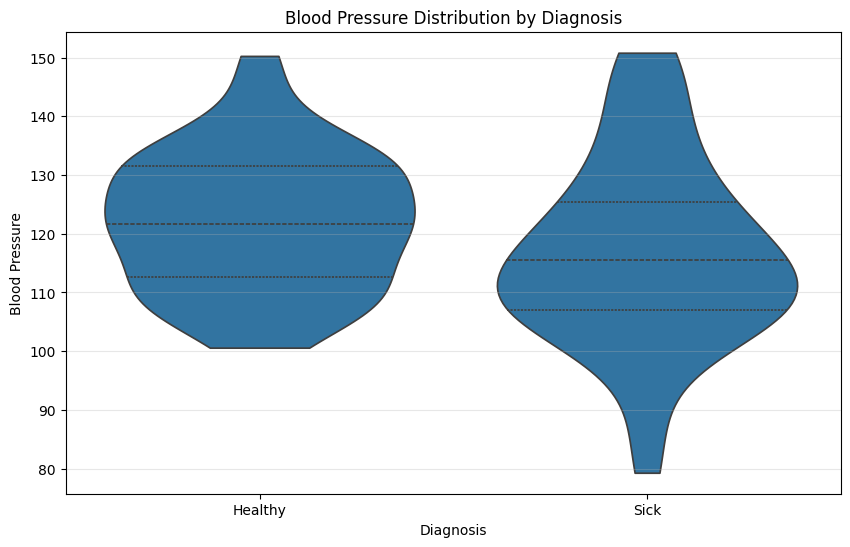

In [29]:
plt.figure(figsize=(10, 6))

diagnosis_order = ['Healthy', 'Sick']

sns.violinplot(
    data=df_medical,
    x='Diagnosis',
    y='BloodPressure',
    order=diagnosis_order,
    inner='quartile',
    cut=0
)

plt.title('Blood Pressure Distribution by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Blood Pressure')
plt.grid(axis='y', alpha=0.3)

plt.show()

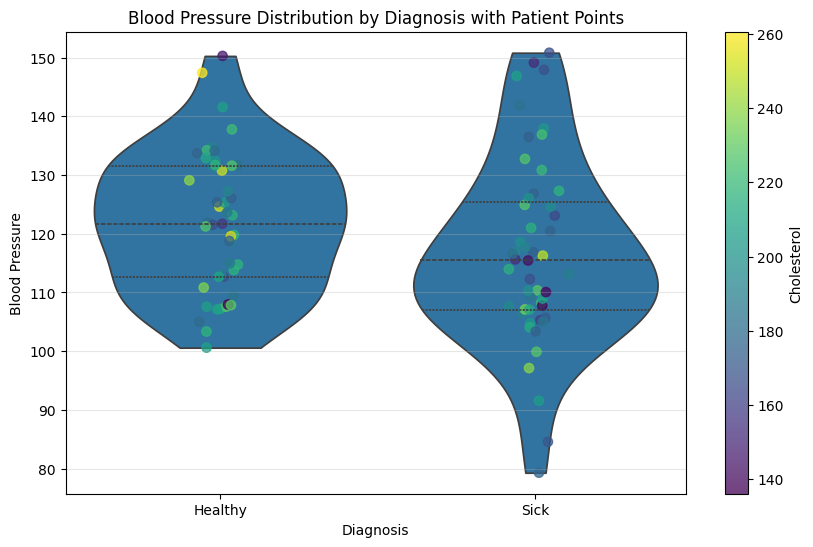

In [30]:
plt.figure(figsize=(10, 6))

diagnosis_order = ['Healthy', 'Sick']

# Violin plot
sns.violinplot(
    data=df_medical,
    x='Diagnosis',
    y='BloodPressure',
    order=diagnosis_order,
    inner='quartile',
    cut=0
)

# تبدیل Diagnosis به موقعیت عددی برای scatter
diagnosis_to_x = {
    'Healthy': 0,
    'Sick': 1
}

rng = np.random.default_rng(42)

x_positions = (
    df_medical['Diagnosis']
    .map(diagnosis_to_x)
    .values
    + rng.normal(0, 0.05, size=len(df_medical))
)

# Scatter plot نقاط واقعی بیماران
scatter = plt.scatter(
    x=x_positions,
    y=df_medical['BloodPressure'],
    c=df_medical['Cholesterol'],
    alpha=0.75,
    s=45
)

plt.colorbar(scatter, label='Cholesterol')

plt.title('Blood Pressure Distribution by Diagnosis with Patient Points')
plt.xlabel('Diagnosis')
plt.ylabel('Blood Pressure')
plt.xticks([0, 1], diagnosis_order)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [32]:
healthy_bp = df_medical[df_medical['Diagnosis'] == 'Healthy']['BloodPressure']
sick_bp = df_medical[df_medical['Diagnosis'] == 'Sick']['BloodPressure']

print("میانگین فشار خون افراد Healthy:")
print(healthy_bp.mean())

print("\nمیانگین فشار خون افراد Sick:")
print(sick_bp.mean())

print("\nمیانه فشار خون افراد Healthy:")
print(healthy_bp.median())

print("\nمیانه فشار خون افراد Sick:")
print(sick_bp.median())

print("\nاختلاف میانگین Sick و Healthy:")
print(sick_bp.mean() - healthy_bp.mean())

میانگین فشار خون افراد Healthy:
122.04707064418531

میانگین فشار خون افراد Sick:
116.7253797804896

میانه فشار خون افراد Healthy:
121.69905615806647

میانه فشار خون افراد Sick:
115.44507714189005

اختلاف میانگین Sick و Healthy:
-5.321690863695707


### Question 3: Analysis of Blood Pressure Distribution by Diagnosis

In this part, the distribution of `BloodPressure` was compared between two diagnosis groups: `Healthy` and `Sick`.

First, a violin plot was used to show the overall distribution of blood pressure in each group. Then, the real patient data points were added on top of the violin plot using a scatter plot. The color of each point represents the patient's `Cholesterol` value.

Based on the plot and the descriptive statistics, the `Healthy` group has a slightly higher center of distribution compared to the `Sick` group. The mean blood pressure for the `Healthy` group is approximately **122.05**, while the mean blood pressure for the `Sick` group is approximately **116.73**. Also, the median blood pressure is approximately **121.70** for the `Healthy` group and **115.45** for the `Sick` group.

The violin plot also shows that the `Sick` group has a wider spread in blood pressure values. In particular, the `Sick` group contains some lower blood pressure values, while both groups have some high blood pressure values close to 150.

Therefore, in this generated dataset, there is a small difference between the blood pressure distributions of `Healthy` and `Sick` patients. The `Healthy` group appears to have a slightly higher central blood pressure, while the `Sick` group shows more variability.

However, this difference should not be interpreted as a real medical relationship. The dataset was generated artificially, and the `Diagnosis` values were assigned randomly rather than being determined based on `BloodPressure`. Therefore, the observed difference is most likely due to randomness in the generated data.

The cholesterol values, shown by the color of the scatter points, do not show a very clear separation pattern between the two diagnosis groups in this plot.